In [1]:
import spd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

['84.65GB', '85.09GB']


In [3]:
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator

In [4]:
N0=64
t=1
n=10
times={}
def compute_times(t_int,ps,n,steps,scheme):
    for p in ps:
        times[(p,t_int)]=np.arange(n)
        for i in np.arange(n):
            N=2**(i+3)//(p+1)
            print(p,N)
            s = SPD_Simulator(p=p,N=(N,N),time_integrator=t_int,cfl_coeff=1.6//(p+1),scheme=scheme)
            s.perform_iterations(steps)
            times[(p,t_int)][i]=s.zone_cycles

In [5]:
compute_times("rk4",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 2.739, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.527, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.538, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.52, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.522, bzcps = 0.001
3 64
t=0.0, steps taken 100, time taken 1.533, bzcps = 0.004
3 128
t=0.0, steps taken 100, time taken 1.539, bzcps = 0.017
3 256
t=0.0, steps taken 100, time taken 1.732, bzcps = 0.061
3 512
t=0.0, steps taken 100, time taken 6.317, bzcps = 0.066
3 1024
t=0.0, steps taken 100, time taken 24.951, bzcps = 0.067
7 1
t=0.0, steps taken 100, time taken 1.563, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 1.532, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 1.524, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 1.532, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 1.543, bzcps = 0.001
7 32
t=0.0, steps taken 100, time taken 1.535, bzcps = 0.004
7 64
t=0.0, steps taken 100, time taken 1.

In [6]:
compute_times("ader",[3,7],n-1,100,"SD")

3 2
t=0.0, steps taken 100, time taken 1.385, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.311, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.32, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.315, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.316, bzcps = 0.001
3 64
t=0.0, steps taken 100, time taken 1.317, bzcps = 0.005
3 128
t=0.0, steps taken 100, time taken 1.359, bzcps = 0.019
3 256
t=0.0, steps taken 100, time taken 4.288, bzcps = 0.024
3 512
t=0.0, steps taken 100, time taken 17.366, bzcps = 0.024
7 1
t=0.0, steps taken 100, time taken 2.139, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 2.071, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 2.067, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 2.062, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 2.078, bzcps = 0.001
7 32
t=0.0, steps taken 100, time taken 2.104, bzcps = 0.003
7 64
t=0.0, steps taken 100, time taken 2.374, bzcps = 0.011
7 128
t=0.0, steps taken 100, time taken 9.0

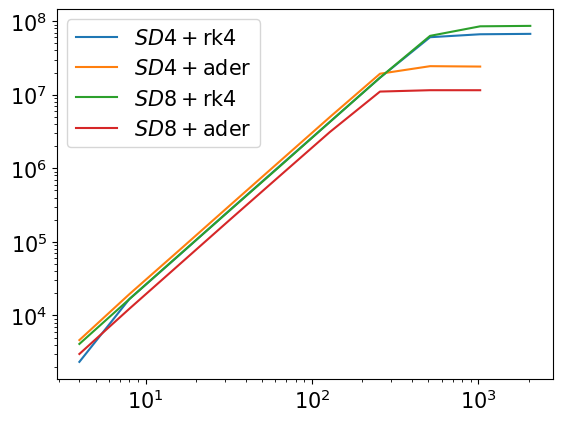

In [7]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    for t_int in ["rk4","ader"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
plt.yscale("log")
plt.xscale("log")
plt.legend()

In [8]:
compute_times("rk3",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 1.164, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 1.172, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 1.163, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 1.168, bzcps = 0.0
3 32
t=0.0, steps taken 100, time taken 1.172, bzcps = 0.001
3 64
t=0.0, steps taken 100, time taken 1.179, bzcps = 0.006
3 128
t=0.0, steps taken 100, time taken 1.177, bzcps = 0.022
3 256
t=0.0, steps taken 100, time taken 1.334, bzcps = 0.079
3 512
t=0.0, steps taken 100, time taken 4.751, bzcps = 0.088
3 1024
t=0.0, steps taken 100, time taken 18.739, bzcps = 0.09
7 1
t=0.0, steps taken 100, time taken 1.198, bzcps = 0.0
7 2
t=0.0, steps taken 100, time taken 1.168, bzcps = 0.0
7 4
t=0.0, steps taken 100, time taken 1.165, bzcps = 0.0
7 8
t=0.0, steps taken 100, time taken 1.175, bzcps = 0.0
7 16
t=0.0, steps taken 100, time taken 1.178, bzcps = 0.001
7 32
t=0.0, steps taken 100, time taken 1.17, bzcps = 0.006
7 64
t=0.0, steps taken 100, time taken 1.1

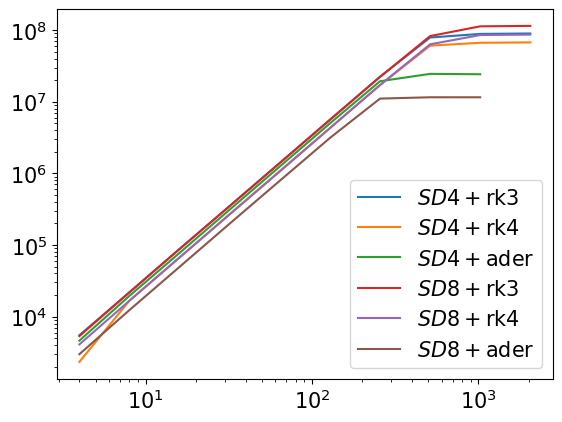

In [9]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    for t_int in ["rk3","rk4","ader"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
plt.yscale("log")
plt.xscale("log")
plt.legend()

In [10]:
compute_times("rk1",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 0.443, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 0.447, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 0.451, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 0.447, bzcps = 0.001
3 32
t=0.0, steps taken 100, time taken 0.455, bzcps = 0.004
3 64
t=0.0, steps taken 100, time taken 0.446, bzcps = 0.015
3 128
t=0.0, steps taken 100, time taken 0.452, bzcps = 0.058
3 256
t=0.0, steps taken 100, time taken 0.561, bzcps = 0.187
3 512
t=0.0, steps taken 100, time taken 1.854, bzcps = 0.226
3 1024
t=0.0, steps taken 100, time taken 5.754, bzcps = 0.292


In [11]:
compute_times("rk2",[3,7],n,100,"SD")

3 2
t=0.0, steps taken 100, time taken 0.805, bzcps = 0.0
3 4
t=0.0, steps taken 100, time taken 0.805, bzcps = 0.0
3 8
t=0.0, steps taken 100, time taken 0.805, bzcps = 0.0
3 16
t=0.0, steps taken 100, time taken 0.815, bzcps = 0.001
3 32
t=0.0, steps taken 100, time taken 0.814, bzcps = 0.002
3 64
t=0.0, steps taken 100, time taken 0.819, bzcps = 0.008
3 128
t=0.0, steps taken 100, time taken 0.823, bzcps = 0.032
3 256
t=0.0, steps taken 100, time taken 0.947, bzcps = 0.111
3 512
t=0.0, steps taken 100, time taken 10.118, bzcps = 0.166


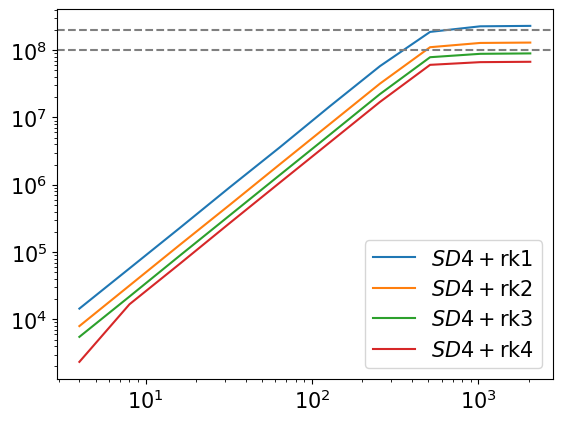

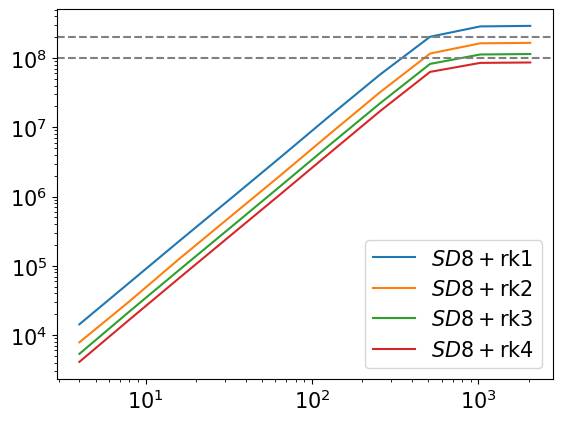

In [12]:
Ns = 2**(2+np.arange(n))
for p in [3,7]:
    fig,axs=plt.subplots(1,1)
    for t_int in ["rk1","rk2","rk3","rk4"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$SD{p+1}+${t_int}")
    plt.axhline(1E+8,ls="--",color="gray")
    plt.axhline(2E+8,ls="--",color="gray")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()

In [13]:
compute_times("rk1",[1],n,100,"FV")

1 4
t=0.0, steps taken 100, time taken 0.727, bzcps = 0.0
1 8
t=0.0, steps taken 100, time taken 0.399, bzcps = 0.0
1 16
t=0.0, steps taken 100, time taken 0.399, bzcps = 0.0
1 32
t=0.0, steps taken 100, time taken 0.397, bzcps = 0.0
1 64
t=0.0, steps taken 100, time taken 0.405, bzcps = 0.001
1 128
t=0.0, steps taken 100, time taken 0.405, bzcps = 0.004
1 256
t=0.0, steps taken 100, time taken 0.404, bzcps = 0.016
1 512
t=0.0, steps taken 100, time taken 0.415, bzcps = 0.063
1 1024
t=0.0, steps taken 100, time taken 0.625, bzcps = 0.168
1 2048
t=0.0, steps taken 100, time taken 2.284, bzcps = 0.184


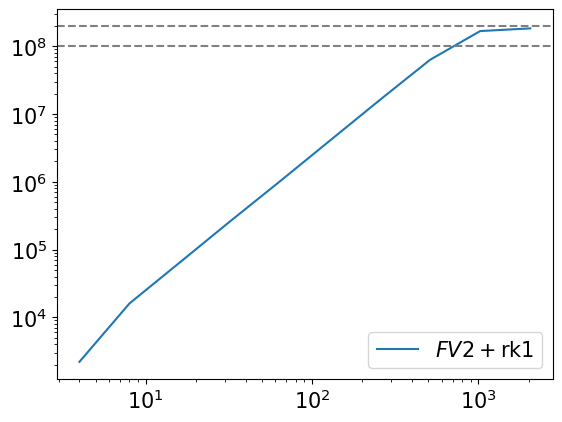

In [14]:
Ns = 2**(2+np.arange(n))
for p in [1]:
    fig,axs=plt.subplots(1,1)
    for t_int in ["rk1"]:
        l = times[(p,t_int)].size
        plt.plot(Ns[:l],times[(p,t_int)],label=f"$FV{p+1}+${t_int}")
    plt.axhline(1E+8,ls="--",color="gray")
    plt.axhline(2E+8,ls="--",color="gray")
    plt.yscale("log")
    plt.xscale("log")
    plt.legend()